In [1]:
from pathlib import Path

import pandas as pd

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"

charges = pd.read_csv(
    RESULTS / "charges" / "hirshfeld_atomic_charges.csv"
)

In [2]:
charges.groupby("system")["hirshfeld_charge"].sum()

system
pdi                           -4.000000e-10
pdi_terminal_functionalized   -2.000000e-10
Name: hirshfeld_charge, dtype: float64

In [3]:
fragment_charges = (
    charges
    .groupby(["system", "region"], dropna=False)
    ["hirshfeld_charge"]
    .sum()
    .reset_index()
)

In [4]:
matched = charges[
    charges["mapping_status"] == "matched"
].copy()

In [5]:
matched_pivot = matched.pivot(
    index="label",
    columns="system",
    values="hirshfeld_charge",
)

In [6]:
matched_pivot["delta_q"] = (
    matched_pivot["pdi_terminal_functionalized"]
    - matched_pivot["pdi"]
)

In [7]:
matched_pivot.reindex(
    matched_pivot["delta_q"].abs().sort_values(
        ascending=False
    ).index
).head(15)

system,pdi,pdi_terminal_functionalized,delta_q
label,,,
N1,-0.070299,-0.024274,0.046025
N2,-0.070299,-0.024274,0.046025
O1,-0.282942,-0.251457,0.031485
O3,-0.282940,-0.251459,0.031481
O2,-0.282944,-0.262083,0.020861
O4,-0.282940,-0.262085,0.020855
C24,0.179109,0.183997,0.004888
C22,0.179112,0.183998,0.004886
C23,0.179111,0.183734,0.004622


## Hirshfeld charge plots

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
    }
)

SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Terminal-functionalized PDI",
}

SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}

REGION_COLORS = {
    "core": "#0018F9",
    "middle": "#6B7CDB",
    "outer": "#F28500",
    "imide": "#D08A3A",
    "carbonyl": "#111111",
    "terminal_left_alpha": "#00A6A6",
    "terminal_left_beta": "#48B0A4",
    "terminal_left_gamma": "#7AC7B7",
    "terminal_right_alpha": "#B00020",
    "terminal_right_beta": "#D14A61",
    "terminal_right_gamma": "#E17C8F",
}

DEFAULT_COLORS = ["#0018F9", "#F28500", "#6B7CDB", "#D08A3A", "#9AA0A6"]

FIGURE_BACKGROUND = "white"
AXIS_COLOR = "black"
GRID_COLOR = "#9AA0A6"

def practical_chemistry_axis(ax, xlabel=None, ylabel=None, title=None, legend=False, legend_loc="best"):
    fig = ax.figure
    fig.patch.set_facecolor(FIGURE_BACKGROUND)
    ax.set_facecolor(FIGURE_BACKGROUND)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_color(AXIS_COLOR)

    ax.tick_params(axis="both", labelsize=14, direction="in", width=1.4, colors=AXIS_COLOR)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(AXIS_COLOR)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if title:
        ax.set_title(title, fontsize=18, fontweight="bold", color=AXIS_COLOR)

    #ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.35, color=GRID_COLOR)

    if legend:
        legend_obj = ax.legend(loc=legend_loc, prop={"size": 11, "weight": "bold"})
        legend_obj.get_frame().set_facecolor(FIGURE_BACKGROUND)
        legend_obj.get_frame().set_edgecolor(AXIS_COLOR)
        for text in legend_obj.get_texts():
            text.set_color(AXIS_COLOR)

    return ax

def bar_colors(values):
    return ["#F28500" if value >= 0 else "#0018F9" for value in values]

matched_charge_comparison = (
    charges.loc[charges["mapping_status"] == "matched"]
    .pivot(index="label", columns="system", values="hirshfeld_charge")
    .dropna()
    .reset_index()
)

label_metadata = (
    charges.loc[charges["mapping_status"] == "matched", ["label", "element", "region"]]
    .drop_duplicates("label")
)

matched_charge_comparison = matched_charge_comparison.merge(label_metadata, on="label", how="left")
matched_charge_comparison["delta_q"] = (
    matched_charge_comparison["pdi_terminal_functionalized"]
    - matched_charge_comparison["pdi"]
)
matched_charge_comparison["abs_delta_q"] = matched_charge_comparison["delta_q"].abs()

region_charge_summary = (
    charges
    .groupby(["system", "region"], dropna=False)["hirshfeld_charge"]
    .sum()
    .reset_index()
)

terminal_charge_summary = (
    charges.loc[
        (charges["system"] == "pdi_terminal_functionalized")
        & (charges["fragment"].isin(["terminal_left", "terminal_right"]))
    ]
    .groupby(["fragment", "subregion"], dropna=False)["hirshfeld_charge"]
    .sum()
    .reset_index()
)

matched_charge_comparison.head()

,label,pdi,pdi_terminal_functionalized,element,region,delta_q,abs_delta_q
0,C1,0.014471,0.013226,C,core,-0.001246,0.001246
1,C10,0.005722,0.003158,C,middle,-0.002564,0.002564
2,C11,-0.020361,-0.020412,C,middle,-0.000050,0.000050
3,C12,-0.007545,-0.009880,C,middle,-0.002335,0.002335
4,C13,-0.028493,-0.030161,C,middle,-0.001667,0.001667


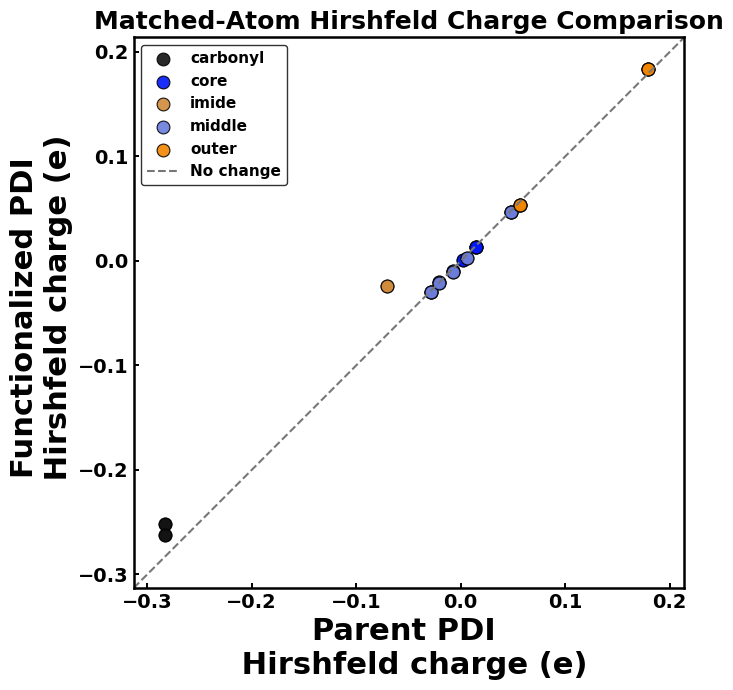

In [9]:
# Parent vs functionalized Hirshfeld charge scatter
fig, ax = plt.subplots(figsize=(8, 7))

for i, (region, group) in enumerate(matched_charge_comparison.groupby("region", dropna=False)):
    color = REGION_COLORS.get(region, DEFAULT_COLORS[i % len(DEFAULT_COLORS)])
    ax.scatter(
        group["pdi"],
        group["pdi_terminal_functionalized"],
        s=85,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        label=str(region),
    )

axis_min = min(matched_charge_comparison["pdi"].min(), matched_charge_comparison["pdi_terminal_functionalized"].min()) - 0.03
axis_max = max(matched_charge_comparison["pdi"].max(), matched_charge_comparison["pdi_terminal_functionalized"].max()) + 0.03
ax.plot([axis_min, axis_max], [axis_min, axis_max], color="#777777", lw=1.5, ls="--", label="No change")

ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)
ax.set_aspect("equal", adjustable="box")
practical_chemistry_axis(
    ax,
    xlabel="Parent PDI \n Hirshfeld charge (e)",
    ylabel="Functionalized PDI \n Hirshfeld charge (e)",
    title="Matched-Atom Hirshfeld Charge Comparison",
    legend=True,
    legend_loc="upper left",
)
plt.tight_layout()
plt.show()

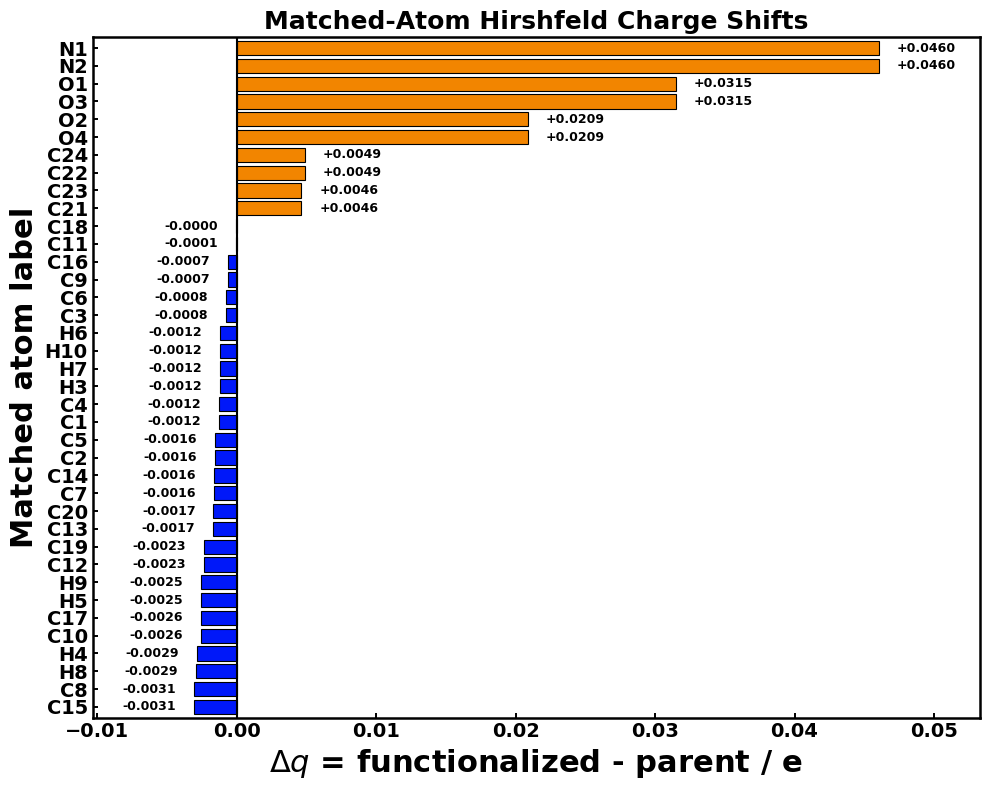

In [10]:
# Delta q bar chart for matched atoms
plot_df = matched_charge_comparison.sort_values("delta_q").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
y_positions = np.arange(len(plot_df))
bars = ax.barh(
    y_positions,
    plot_df["delta_q"],
    color=bar_colors(plot_df["delta_q"]),
    edgecolor="black",
    linewidth=0.8,
)
ax.axvline(0, color="black", lw=1.5)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["label"])

delta_values = plot_df["delta_q"].to_numpy()
max_abs_delta = np.nanmax(np.abs(delta_values)) if len(delta_values) else 0.0
label_offset = max(max_abs_delta * 0.028, 0.0007)
x_padding = max(max_abs_delta * 0.13, 0.0045)
label_x_positions = np.where(
    delta_values >= 0,
    delta_values + label_offset,
    delta_values - label_offset,
)
label_alignments = ["left" if value >= 0 else "right" for value in delta_values]

x_min = min(delta_values.min(), label_x_positions.min(), 0.0) - x_padding
x_max = max(delta_values.max(), label_x_positions.max(), 0.0) + x_padding
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.6, len(plot_df) - 0.4)

for bar, value, label_x, ha in zip(bars, delta_values, label_x_positions, label_alignments):
    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.4f}",
        va="center",
        ha=ha,
        fontsize=9,
        fontweight="bold",
        color=AXIS_COLOR,
        clip_on=True,
    )

practical_chemistry_axis(
    ax,
    xlabel=r"$\Delta q$ = functionalized - parent / e",
    ylabel="Matched atom label",
    title="Matched-Atom Hirshfeld Charge Shifts",
)
plt.tight_layout()
plt.show()
